<a href="https://colab.research.google.com/github/ZethetaIntern/logischain-ai-8/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LogisChain AI — 01: Exploratory Data Analysis

Explore synthetic supply chain and financial data generated by `SyntheticDataGenerator`.

**Goals:**
- Understand carrier, shipment, and financial data distributions
- Identify class imbalance in default/failure labels
- Map supply chain network topology
- Baseline correlation analysis

In [6]:
import sys; sys.path.insert(0, '/content/logischain-ai-8')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from src.data.pipeline import SyntheticDataGenerator
from src.utils.visualizations import plot_risk_score_distribution

sns.set_theme(style='whitegrid')
gen = SyntheticDataGenerator(seed=42)
data = gen.generate_all()
carriers = data['carriers']
shipments = data['shipments']
financial = data['financial']
print(f'Carriers: {carriers.shape}, Shipments: {shipments.shape}, Financial: {financial.shape}')

Carriers: (500, 38), Shipments: (50000, 18), Financial: (200, 18)


In [7]:
!git clone https://github.com/ZethetaIntern/logischain-ai-8.git
import sys
sys.path.insert(0, '/content/logischain-ai-8')

fatal: destination path 'logischain-ai-8' already exists and is not an empty directory.


Carrier failure rate: 4.40%


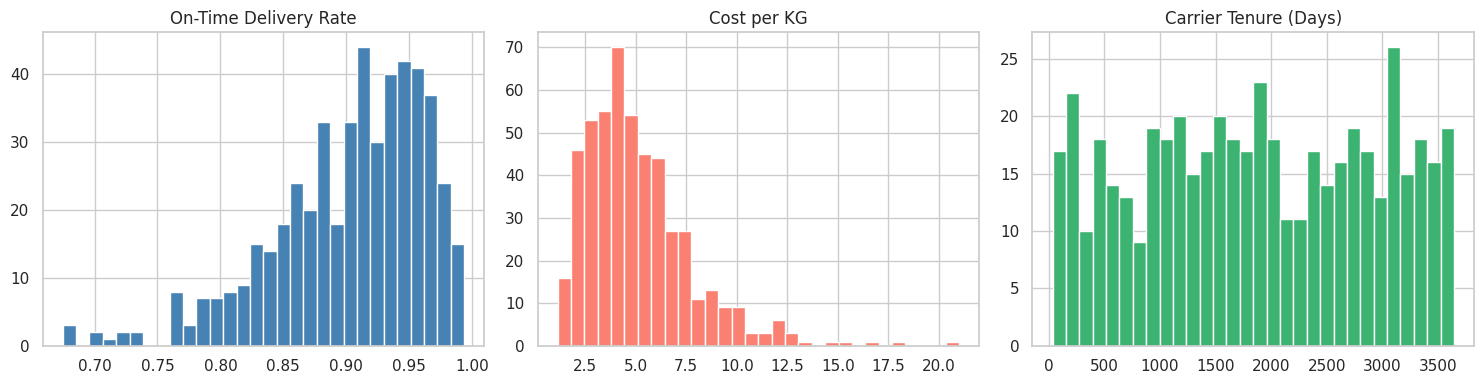

In [8]:
# Carrier failure rate
failure_rate = carriers['carrier_failure'].mean()
print(f'Carrier failure rate: {failure_rate:.2%}')
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(carriers['on_time_delivery_rate'], bins=30, color='steelblue')
axes[0].set_title('On-Time Delivery Rate')
axes[1].hist(carriers['cost_per_kg'], bins=30, color='salmon')
axes[1].set_title('Cost per KG')
axes[2].hist(carriers['carrier_tenure_days'], bins=30, color='mediumseagreen')
axes[2].set_title('Carrier Tenure (Days)')
plt.tight_layout()
plt.show()

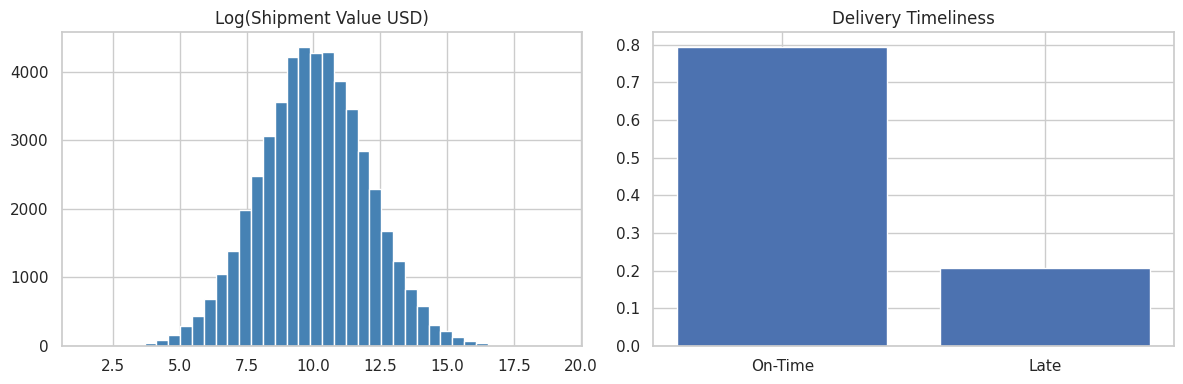

In [9]:
# Shipment value distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log1p(shipments['value_usd']), bins=40, color='steelblue')
axes[0].set_title('Log(Shipment Value USD)')
axes[1].bar(['On-Time', 'Late'], [shipments['on_time'].mean(), 1-shipments['on_time'].mean()])
axes[1].set_title('Delivery Timeliness')
plt.tight_layout()
plt.show()

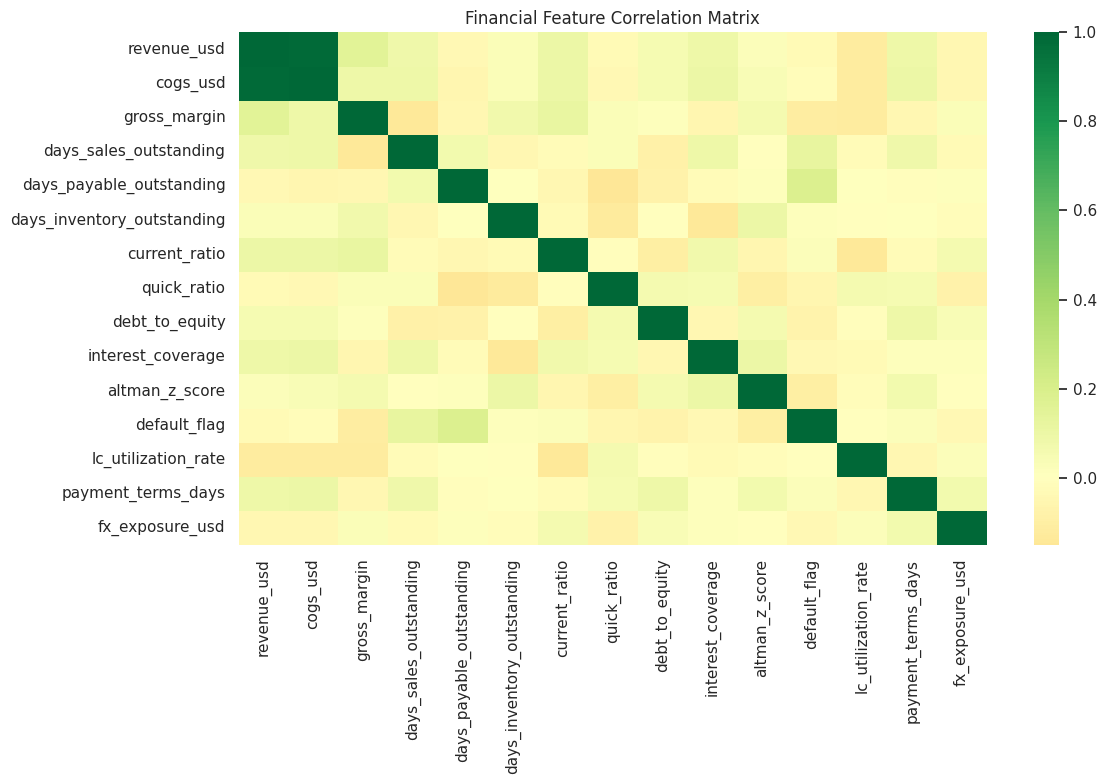

In [10]:
# Financial data correlations
num_cols = financial.select_dtypes(include=np.number).columns.tolist()
corr = financial[num_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='RdYlGn', center=0, fmt='.2f', annot=False)
plt.title('Financial Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [11]:
# Supply chain network
from src.features.supply_chain_features import NetworkFeatureExtractor
extractor = NetworkFeatureExtractor()
G = extractor.build_graph(shipments)
stats = extractor.get_network_stats(G)
print('Network stats:', stats)
node_feats = extractor.extract_node_features(G)
print(node_feats.sort_values('betweenness_centrality', ascending=False).head(10))

Network stats: {'num_nodes': 13, 'num_edges': 62, 'density': 0.3974358974358974, 'is_dag': False, 'avg_shortest_path': -1}
  node  degree_centrality  betweenness_centrality  eigenvector_centrality  \
0   CN           0.666667                     0.0           5.236078e-105   
1   GB           0.666667                     0.0            3.347283e-01   
2   KR           0.666667                     0.0           5.236078e-105   
3   SG           0.666667                     0.0            2.959388e-01   
4   BR           0.666667                     0.0           5.236078e-105   
5   FR           0.666667                     0.0            3.380352e-01   
6   JP           1.166667                     0.0            2.605471e-01   
7   US           1.333333                     0.0            5.148505e-01   
8   CA           0.666667                     0.0            3.292647e-01   
9   DE           1.166667                     0.0            3.417933e-01   

   pagerank  hub_score  autho